# Random Walk 1D Statistics

## Why are we interested in random walk statistics?

Similar to the Gambler's Ruin simulation , we are **not** just interested in the results of one random walk. We are more interested in what happens when we execute the random walk over and over again. Can we see trends or averages that characterize the way a molecule moves at random inside a cell?

For example:

> How far away from the starting point on average will a random walker wander based on number of steps taken?

> What is the distribution of ending points of random walks look like?

> What happens if we "bias" the random walk by giving it a nudge (higher probability) to move in one direction versus another?


To capture this important information, we must run the random walk hundreds or thousands of times and gather **statistics** on the outcomes.




## Plotting a histogram of random walk end position

In the cell below, we will execute multiple 1D random walks with the same input parameter (num_steps) and capture data on the ending position of each walk.

Then, we will print the key statistics (averages) for the simulation and plot a special kind of graph, called a **histogram** which categories and plots the random walk results by end position. A histogram is a graphical display of data using bars of different heights. In our case, we will use a histogram to show the frequency distribution of the ending position of each random walk.

Below is an example of a **histogram** we will run.

<img src="rw1d_hist1.png" width="500" align="center">

# Exercise: Random Walk 1D Statistics

In the cell below, **you are asked to complete the for-loop** which executes a random walk a specific number of times (in variable called **num_walks**). The number of steps in each walk is controlled by user input variable (**num_steps**).


Only three or four lines of code will suffice to solve problem, so don't get too verbose!


**Note: Solution to this exercise is given a few cells below if you get stuck.**

Don't give up too soon, however- This may require a little thought.


Enter number of steps for each walk:1000
 For steps= 1000, average final position =   0.9
 For steps= 1000, average distance squared from center = 983.4


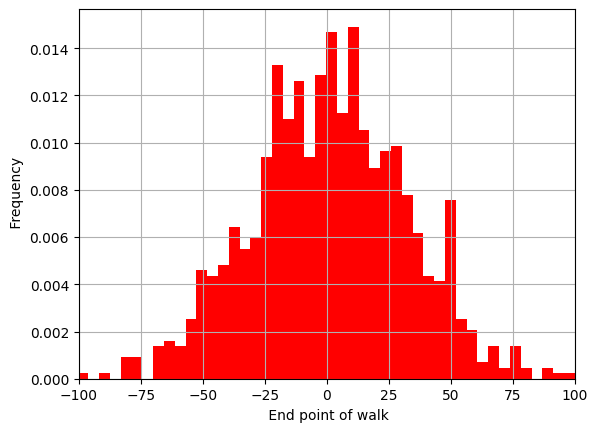

In [6]:
#  Simple python random walk in 1D
#  Plots histogram of ending positions

import random
import numpy as np
import matplotlib.pyplot as plt

def random_walk(steps):
    """  Performs 1D random walk with number steps = steps """

    walk = np.zeros(steps+1)
    for i in range(steps):
        walk[i+1] = walk[i] + random.choice([-1,1])

    return walk

num_walks = 1000
num_steps = int(input('Enter number of steps for each walk:'))



#  Perform random walks and save ending position of each walk
last_pos = np.zeros(num_walks)  # array to store last position of each walk


#######################################################################
#  YOUR CODE goes HERE:
#    Add a for-loop to conduct random walk num_walks times
#     1. Execute walk
#     2. Store end position of walk in last_pos array
#
#    Compute the average of the square of last
#    positions (held in last_pos array above
#    and store result in variable called:
#    'ave_dist2'. This variable is used in plot below
#
#########################################################################


for walk in range(num_walks):
  steps = random_walk(num_walks)
  last_pos[walk] = steps[-1]

ave_dist2 = np.mean(last_pos ** 2)

avg_last_pos = np.mean(last_pos)


print (f' For steps= {num_steps}, average final position = {avg_last_pos:5.1f}')
print (f' For steps= {num_steps}, average distance squared from center = {ave_dist2:5.1f}')


#  Set plot title , legend, and grid
#plt.title(f'Histogram of 1D walk , #steps = {num_steps}, $\langle x^2 \rangle$ = {ave_dist2: 6.1f}')
plt.hist(last_pos, bins=50, color='red', density=True)
plt.xlabel(' End point of walk')
plt.ylabel(' Frequency')
plt.xlim(-100, 100)
plt.savefig('rw1d_hist1.png')
plt.grid(True)
plt.show()

In [7]:
num_steps = 1000
num_walks = 1000

walks = np.zeros((num_walks, num_steps+1))

for i in range(num_walks):
    walks[i] = random_walk(num_steps)

print(walks)

[[  0.  -1.  -2. ...   6.   7.   6.]
 [  0.  -1.   0. ...  12.  13.  12.]
 [  0.   1.   0. ... -10. -11. -10.]
 ...
 [  0.   1.   0. ...  24.  25.  26.]
 [  0.  -1.   0. ...  48.  49.  48.]
 [  0.  -1.   0. ...  16.  17.  16.]]


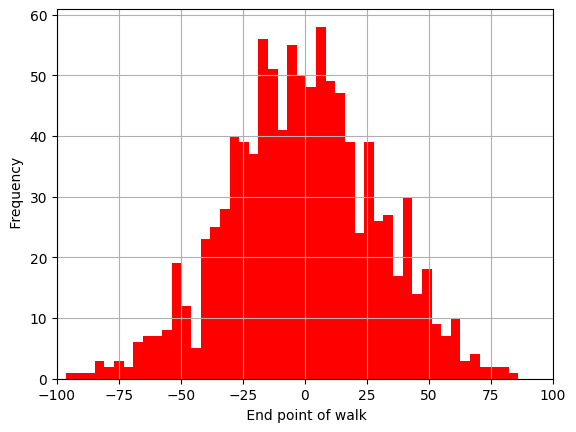

In [8]:
pos = walks[:, 1000]

plt.hist(pos, bins=50, color='red')
plt.xlabel(' End point of walk')
plt.ylabel(' Frequency')
plt.xlim(-100, 100)
plt.savefig('rw1d_hist1.png')
plt.grid(True)
plt.show()

<hr style="border:2px solid blue"> </hr>
<hr style="border:2px solid blue"> </hr>

# Running Experiments with Random Walk Statistics


**Now, with the our statistics program running, we can run experiments!!**



One key question we might have is how far a random walker gets from the starting point for  given number of
"time-steps". In other words, how much "territory" will a randomly moving molecule inside a cell explore?


>  1. A prediction from **diffusion theory** is that a random walker will be (on average) $\sqrt{N}$ away from starting point after $N$ time-steps of one unit each. For example, if we run a random walk with 100 steps, we would expect the walker to be $\sqrt{100}$ or 10 units away from starting point on average.  


Devise an experiment to test this assumption with the program, run the experiment, and plot your result (manually). For example, you may want to vary the number of steps from 100 to 1000 by 100, and plot the average distance versus number of steps. Note: Keep number of simulations to 1000 or less for each run, to keep the runtime down.

<hr style="border:2px solid blue"> </hr>
<hr style="border:2px solid blue"> </hr>

Steps (N)   Theory (√N)    Simulated Avg Distance   
100         10.00          8.03                     
200         14.14          10.95                    
300         17.32          13.85                    
400         20.00          15.89                    
500         22.36          18.27                    
600         24.49          19.43                    
700         26.46          21.67                    
800         28.28          23.67                    
900         30.00          23.45                    
1000        31.62          25.71                    


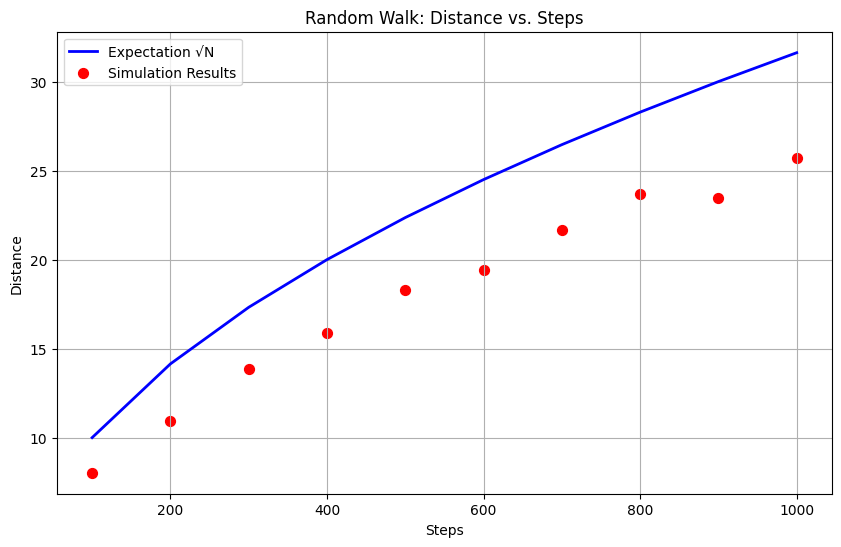

In [17]:
import random
import numpy as np
import matplotlib.pyplot as plt

def random_walk(steps):
    walk = np.zeros(steps + 1)
    for i in range(steps):
        walk[i+1] = walk[i] + random.choice([-1, 1])
    return walk

step_sizes = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
num_simulations = 1000

avg_distances = []
distances = []

print(f"{'Steps (N)':<12}{'Theory (√N)':<15}{'Simulated Avg Distance':<25}")

for steps in step_sizes:
    last_pos = np.zeros(num_simulations)

    for sim in range(num_simulations):
        walk = random_walk(steps)
        last_pos[sim] = walk[-1]

    avg_abs_dist = np.mean(np.abs(last_pos))
    avg_distances.append(avg_abs_dist)

    theory_dist = np.sqrt(steps)
    distances.append(theory_dist)

    print(f"{steps:<12}{theory_dist:<15.2f}{avg_abs_dist:<25.2f}")

plt.figure(figsize=(10, 6))
plt.plot(step_sizes, distances, label='Expectation √N', color='blue', linewidth=2)
plt.scatter(step_sizes, avg_distances, label='Simulation Results', color='red', marker='o', s=50)

plt.title('Random Walk: Distance vs. Steps')
plt.xlabel('Steps')
plt.ylabel('Distance')
plt.grid(True)
plt.legend()
plt.show()